# Healthcare Risk Adjustment Analytics and Suspect Member Prioritization

## Portfolio objective

This project simulates a healthcare payer analytics workflow for risk adjustment, suspect member prioritization, and plan-level financial interpretation. The goal is to show how a data scientist or healthcare data analyst can turn member demographics, utilization, chronic-condition signals, and risk scores into an actionable review queue for coding, documentation, and care-gap operations.

## Business problem

Health plans need to identify members whose documented risk may not fully reflect their clinical complexity. A targeted analytics workflow can help risk adjustment, quality, and care management teams prioritize chart review and provider outreach while staying transparent about model performance.

## Dataset note

The data in this notebook is fully synthetic and HIPAA-safe. It is designed to mimic common healthcare payer variables such as RAF score, member months, actuarial value, chronic burden, claims utilization, care gaps, and HCC-like documentation indicators.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.risk_adjustment_pipeline import (
    CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    NUMERIC_FEATURES,
    TARGET,
    classification_summary,
    feature_importance,
    generate_synthetic_members,
    plan_transfer_table,
    provider_action_table,
    score_members,
    summarize_priority_queue,
    train_models,
)

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
for folder in [DATA_DIR, OUTPUT_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


## 1. Synthetic member population

The member table is built with healthcare domain logic: older age and chronic conditions increase utilization; utilization influences documentation opportunities; and plan actuarial value and member months support downstream risk transfer calculations.


In [2]:
df = generate_synthetic_members(n_members=5000, seed=42)
raw_data_path = DATA_DIR / "synthetic_healthcare_risk_members.csv"
df.to_csv(raw_data_path, index=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Synthetic suspect rate: {df[TARGET].mean():.1%}")
display(df.head(10))


Rows: 5,000
Columns: 26
Synthetic suspect rate: 17.9%


,MemberID,Region,ProviderGroup,Age,Gender,Visits,ER_Visits,Inpatient_Admits,RX_Count,Diabetes,COPD,CKD,CHF,Depression,ChronicCount,Prior_HCC_Flag,New_Diagnosis_Flag,CareGapCount,RAF_Score,PaidClaimsPMPM,SuspectFlag,PlanID,MemberMonths,AV,AgeBand,OpportunitySegment
0,100000,South,BayCare Network,77,M,6,0,0,3,1,0,0,0,0,1,0,0,1,0.970,745.720,0,PlanC_Bronze,6,0.600,75+,Monitor
1,100001,Midwest,Frontier Health,82,M,4,2,0,8,1,1,0,1,0,3,1,0,1,2.021,"1,565.390",1,PlanA_Silver,12,0.700,75+,High RAF suspect
2,100002,Northeast,Golden Valley,59,F,5,0,0,5,1,0,0,0,0,1,0,1,1,0.853,648.740,0,PlanC_Bronze,12,0.600,50-64,Monitor
3,100003,South,BayCare Network,34,F,1,0,0,2,0,0,0,0,1,1,0,0,3,0.516,486.280,0,PlanB_Gold,12,0.800,18-34,Care gap follow-up
4,100004,West,Alpha Medical Group,82,F,3,0,0,2,1,0,0,0,0,1,0,0,1,0.861,745.050,0,PlanB_Gold,12,0.800,75+,Monitor
5,100005,Northeast,Delta IPA,38,F,2,0,0,1,0,0,0,0,0,0,0,0,0,0.248,559.790,0,PlanC_Bronze,6,0.600,35-49,Monitor
6,100006,South,Golden Valley,59,F,6,0,0,4,0,0,0,0,1,1,0,1,0,0.444,614.350,1,PlanA_Silver,3,0.700,50-64,Documentation suspect
7,100007,South,Frontier Health,50,M,4,1,0,4,1,0,0,0,0,1,0,0,1,0.581,"1,085.930",0,PlanB_Gold,9,0.800,50-64,Monitor
8,100008,West,Frontier Health,47,F,3,0,0,2,0,0,0,0,1,1,1,0,1,0.820,589.380,0,PlanA_Silver,9,0.700,35-49,Monitor
9,100009,Midwest,Delta IPA,66,F,3,2,1,1,0,0,0,0,1,1,0,0,2,0.636,"1,843.390",1,PlanA_Silver,12,0.700,65-74,Documentation suspect


## 2. Data quality and data dictionary

Before modeling, the workflow checks completeness, feature types, target prevalence, and expected healthcare relationships such as chronic burden versus utilization and RAF score.


In [3]:
data_dictionary = pd.DataFrame(
    [
        ("MemberID", "Synthetic member identifier; no real PHI."),
        ("Region, ProviderGroup", "Operational segments for network and market analysis."),
        ("Age, Gender, AgeBand", "Demographic attributes used for profiling and fairness checks."),
        ("Visits, ER_Visits, Inpatient_Admits, RX_Count", "Healthcare utilization signals."),
        ("Diabetes, COPD, CKD, CHF, Depression", "Synthetic chronic condition indicators."),
        ("ChronicCount", "Total chronic-condition burden."),
        ("Prior_HCC_Flag, New_Diagnosis_Flag", "HCC-like prior documentation and new diagnosis signals."),
        ("CareGapCount", "Open care or documentation gap count."),
        ("RAF_Score", "Synthetic risk adjustment factor score."),
        ("PaidClaimsPMPM", "Synthetic paid claims per member per month."),
        ("PlanID, MemberMonths, AV", "Plan and enrollment fields used for transfer modeling."),
        ("SuspectFlag", "Target: member should be prioritized for documentation/chart-review workflow."),
    ],
    columns=["Field", "Meaning"],
)

display(data_dictionary)

quality_summary = pd.DataFrame({
    "MissingValues": df.isna().sum(),
    "UniqueValues": df.nunique(),
    "DataType": df.dtypes.astype(str),
}).sort_values("MissingValues", ascending=False)
display(quality_summary)

prevalence = df[TARGET].value_counts(normalize=True).rename("Share").to_frame()
display(prevalence)


,Field,Meaning
0,MemberID,Synthetic member identifier; no real PHI.
1,"Region, ProviderGroup",Operational segments for network and market an...
2,"Age, Gender, AgeBand",Demographic attributes used for profiling and ...
3,"Visits, ER_Visits, Inpatient_Admits, RX_Count",Healthcare utilization signals.
4,"Diabetes, COPD, CKD, CHF, Depression",Synthetic chronic condition indicators.
5,ChronicCount,Total chronic-condition burden.
6,"Prior_HCC_Flag, New_Diagnosis_Flag",HCC-like prior documentation and new diagnosis...
7,CareGapCount,Open care or documentation gap count.
8,RAF_Score,Synthetic risk adjustment factor score.
9,PaidClaimsPMPM,Synthetic paid claims per member per month.


,MissingValues,UniqueValues,DataType
MemberID,0,5000,int64
Region,0,4,object
AgeBand,0,5,object
AV,0,3,float64
MemberMonths,0,4,int64
PlanID,0,3,object
SuspectFlag,0,2,int64
PaidClaimsPMPM,0,4889,float64
RAF_Score,0,1429,float64
CareGapCount,0,7,int64


,Share
SuspectFlag,
0,0.821
1,0.179


## 3. Exploratory healthcare risk analysis

The EDA focuses on explainable signals that a payer analytics or healthcare operations team would care about: chronic burden, RAF score, claims PMPM, provider group variation, and care-gap concentration.


In [4]:
kpi_summary = pd.DataFrame(
    {
        "Metric": [
            "Members",
            "Suspect rate",
            "Average RAF score",
            "Average claims PMPM",
            "Average chronic count",
            "Members with 3+ care gaps",
        ],
        "Value": [
            f"{len(df):,}",
            f"{df[TARGET].mean():.1%}",
            f"{df['RAF_Score'].mean():.3f}",
            f"${df['PaidClaimsPMPM'].mean():,.0f}",
            f"{df['ChronicCount'].mean():.2f}",
            f"{(df['CareGapCount'] >= 3).mean():.1%}",
        ],
    }
)
display(kpi_summary)

segment_summary = (
    df.groupby("OpportunitySegment")
    .agg(
        Members=("MemberID", "count"),
        SuspectRate=(TARGET, "mean"),
        AvgRAF=("RAF_Score", "mean"),
        AvgClaimsPMPM=("PaidClaimsPMPM", "mean"),
        AvgCareGaps=("CareGapCount", "mean"),
    )
    .sort_values("SuspectRate", ascending=False)
)
display(segment_summary)


,Metric,Value
0,Members,"5,000"
1,Suspect rate,17.9%
2,Average RAF score,0.652
3,Average claims PMPM,$832
4,Average chronic count,0.62
5,Members with 3+ care gaps,2.7%


,Members,SuspectRate,AvgRAF,AvgClaimsPMPM,AvgCareGaps
OpportunitySegment,,,,,
Documentation suspect,493,1.000,0.528,924.982,0.870
High RAF suspect,403,1.000,1.338,"1,456.557",1.206
Care gap follow-up,57,0.000,0.942,"1,043.441",3.193
Monitor,4047,0.000,0.595,755.772,0.479


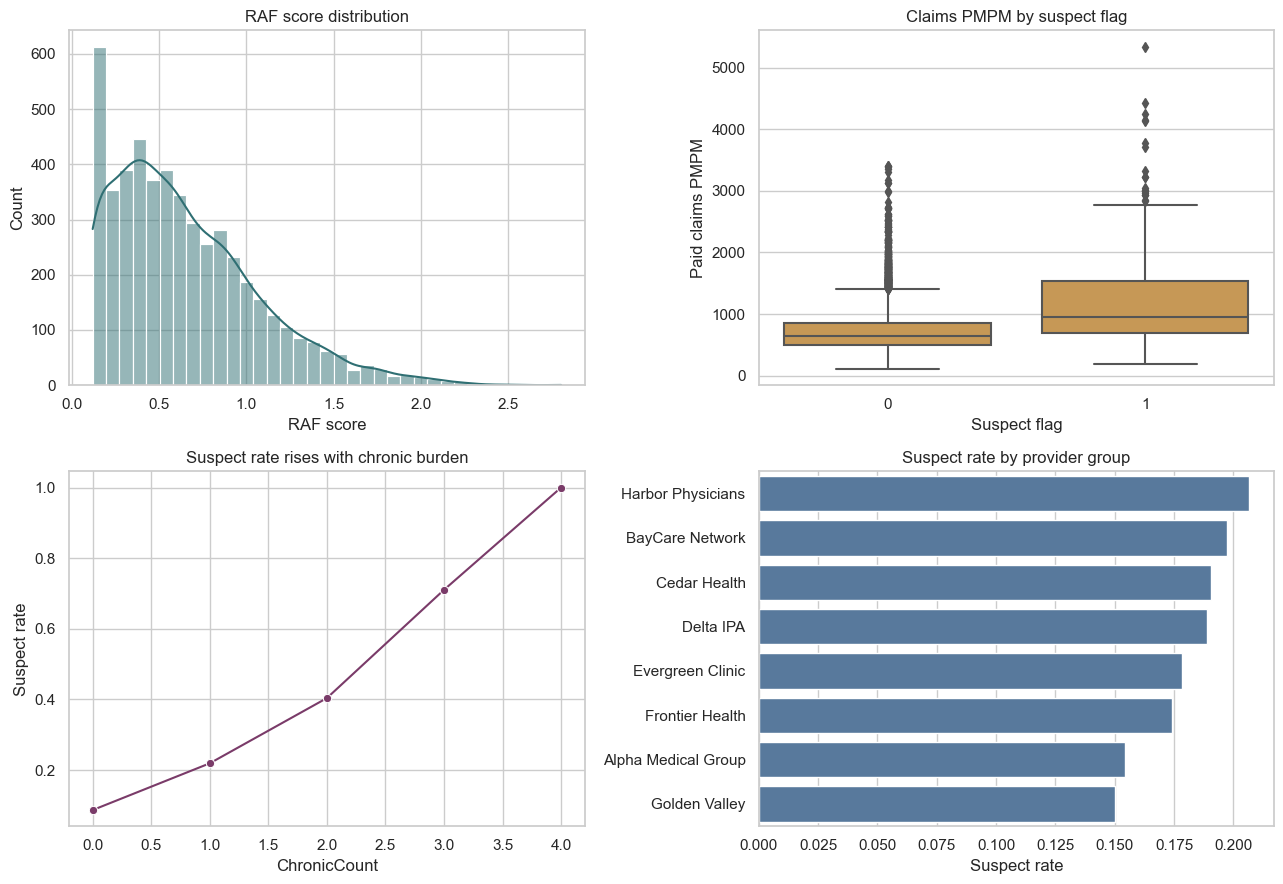

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["RAF_Score"], bins=35, kde=True, ax=axes[0, 0], color="#2f6f73")
axes[0, 0].set_title("RAF score distribution")
axes[0, 0].set_xlabel("RAF score")

sns.boxplot(data=df, x=TARGET, y="PaidClaimsPMPM", ax=axes[0, 1], color="#d99b43")
axes[0, 1].set_title("Claims PMPM by suspect flag")
axes[0, 1].set_xlabel("Suspect flag")
axes[0, 1].set_ylabel("Paid claims PMPM")

chronic_rate = df.groupby("ChronicCount")[TARGET].mean().reset_index()
sns.lineplot(data=chronic_rate, x="ChronicCount", y=TARGET, marker="o", ax=axes[1, 0], color="#7a3b69")
axes[1, 0].set_title("Suspect rate rises with chronic burden")
axes[1, 0].set_ylabel("Suspect rate")

provider_rates = (
    df.groupby("ProviderGroup")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=provider_rates, y="ProviderGroup", x=TARGET, ax=axes[1, 1], color="#4c78a8")
axes[1, 1].set_title("Suspect rate by provider group")
axes[1, 1].set_xlabel("Suspect rate")
axes[1, 1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "eda_healthcare_risk_signals.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. Predictive modeling

Two supervised models are trained to estimate the probability that a member should be prioritized for documentation review. The model is evaluated with ROC AUC, average precision, recall, precision, and top-decile lift because the business workflow is a ranked queue, not just a yes/no classifier.


In [6]:
model_run = train_models(df, seed=42)
metrics = model_run.metrics.copy()
metrics_rounded = metrics.copy()
for col in metrics_rounded.columns:
    if col != "Model":
        metrics_rounded[col] = metrics_rounded[col].round(3)

metrics.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
display(metrics_rounded)

best_model_name = metrics.iloc[0]["Model"]
best_model = model_run.models[best_model_name]
print(f"Best model selected for operational scoring: {best_model_name}")


,Model,ROC_AUC,Average_Precision,Precision_at_0_50,Recall_at_0_50,F1_at_0_50,Top_Decile_Lift,Top_Decile_Capture
0,Logistic Regression,0.792,0.526,0.381,0.725,0.499,3.494,0.349
1,Random Forest,0.784,0.499,0.380,0.691,0.491,3.420,0.342


Best model selected for operational scoring: Logistic Regression


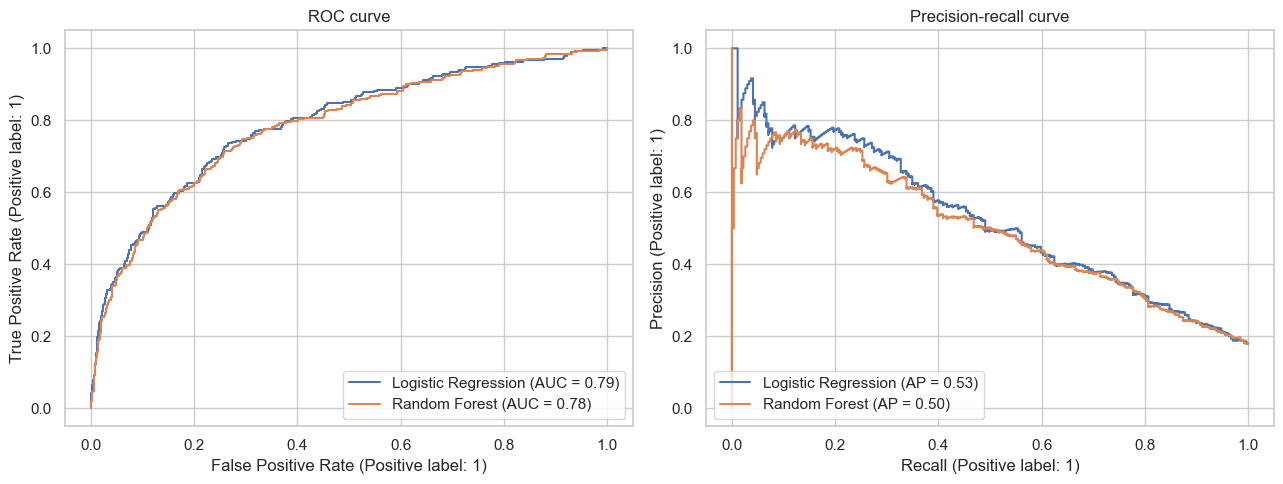

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, model in model_run.models.items():
    probability = model.predict_proba(model_run.x_test)[:, 1]
    RocCurveDisplay.from_predictions(model_run.y_test, probability, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(model_run.y_test, probability, name=name, ax=axes[1])
axes[0].set_title("ROC curve")
axes[1].set_title("Precision-recall curve")
plt.tight_layout()
fig.savefig(FIG_DIR / "model_roc_pr_curves.png", dpi=180, bbox_inches="tight")
plt.show()


,precision,recall,f1-score,support
0,0.925,0.742,0.824,"1,231.000"
1,0.381,0.725,0.499,269.000
accuracy,0.739,0.739,0.739,0.739
macro avg,0.653,0.734,0.662,"1,500.000"
weighted avg,0.828,0.739,0.766,"1,500.000"


Confusion matrix at 0.50 threshold
[[914 317]
 [ 74 195]]


,Feature,AbsoluteCoefficient
0,ChronicCount,0.421
1,PaidClaimsPMPM,0.375
2,CareGapCount,0.327
3,New_Diagnosis_Flag,0.295
4,Prior_HCC_Flag,0.240
5,ProviderGroup_Golden Valley,0.233
6,ProviderGroup_Harbor Physicians,0.187
7,ProviderGroup_Frontier Health,0.180
8,Age,0.131
9,ProviderGroup_Alpha Medical Group,0.131


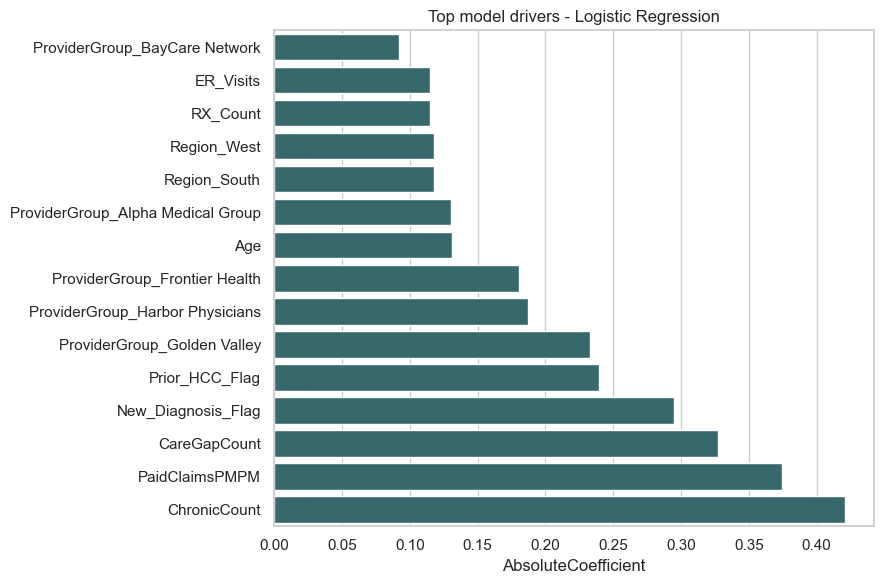

In [8]:
class_report, confusion = classification_summary(best_model, model_run.x_test, model_run.y_test)
display(class_report.round(3))
print("Confusion matrix at 0.50 threshold")
print(confusion)

importance = feature_importance(best_model, top_n=15)
importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
display(importance)

importance_col = [col for col in importance.columns if col != "Feature"][0]
plt.figure(figsize=(9, 6))
sns.barplot(data=importance.sort_values(importance_col), x=importance_col, y="Feature", color="#2f6f73")
plt.title(f"Top model drivers - {best_model_name}")
plt.xlabel(importance_col)
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Operational prioritization queue

The trained model is converted into a ranked workflow. Instead of reviewing every member, the business can review the highest-probability tiers first, where the suspect rate and estimated opportunity are meaningfully higher than the population baseline.


In [9]:
scored_members = score_members(df, best_model)
priority_summary = summarize_priority_queue(scored_members)
provider_table = provider_action_table(scored_members)

top_members = scored_members[
    [
        "MemberID",
        "ProviderGroup",
        "Region",
        "PlanID",
        "Age",
        "ChronicCount",
        "RAF_Score",
        "PaidClaimsPMPM",
        "CareGapCount",
        "SuspectProbability",
        "PriorityTier",
        "EstimatedOpportunityPMPM",
    ]
].head(25)

scored_members.to_csv(OUTPUT_DIR / "scored_member_priority_queue.csv", index=False)
priority_summary.to_csv(OUTPUT_DIR / "priority_tier_summary.csv", index=False)
provider_table.to_csv(OUTPUT_DIR / "provider_action_table.csv", index=False)
top_members.to_csv(OUTPUT_DIR / "top_25_member_opportunities.csv", index=False)

display(priority_summary.round(3))
display(provider_table.head(10).round(3))
display(top_members.round(3))


,PriorityTier,Members,SuspectRate,AvgProbability,AvgRAF,AvgClaimsPMPM,EstOpportunityPMPM
0,Monitor,3500,0.094,0.315,0.513,645.720,15.119
1,Medium,1000,0.276,0.637,0.864,"1,072.487",49.870
2,High,350,0.514,0.827,1.126,"1,481.248",83.534
3,Critical,150,0.747,0.936,1.379,"2,067.672",114.833


,ProviderGroup,Members,SuspectRate,AvgRAF,AvgClaimsPMPM,CriticalMembers,EstOpportunityPMPM
0,Harbor Physicians,590,0.207,0.674,864.859,30,33.238
1,Frontier Health,695,0.174,0.643,819.048,27,31.247
2,BayCare Network,558,0.197,0.672,835.857,19,31.657
3,Cedar Health,593,0.191,0.654,844.446,18,30.733
4,Golden Valley,612,0.150,0.628,830.766,17,25.848
5,Delta IPA,619,0.189,0.652,829.820,16,29.809
6,Alpha Medical Group,700,0.154,0.628,797.730,12,26.963
7,Evergreen Clinic,633,0.179,0.670,843.485,11,29.838


,MemberID,ProviderGroup,Region,PlanID,Age,ChronicCount,RAF_Score,PaidClaimsPMPM,CareGapCount,SuspectProbability,PriorityTier,EstimatedOpportunityPMPM
0,103224,Cedar Health,West,PlanA_Silver,84,4,2.460,"4,143.760",2,0.994,Critical,213.890
1,100213,Harbor Physicians,South,PlanA_Silver,58,3,1.515,"4,424.550",1,0.992,Critical,131.520
2,103710,Frontier Health,Northeast,PlanA_Silver,60,4,2.059,"1,660.700",3,0.990,Critical,178.300
3,100408,BayCare Network,West,PlanA_Silver,57,3,1.641,"1,729.460",6,0.989,Critical,142.070
4,102895,Frontier Health,West,PlanB_Gold,77,3,1.789,"2,194.030",4,0.988,Critical,176.680
5,102970,Frontier Health,Midwest,PlanB_Gold,68,3,1.574,"2,719.610",3,0.987,Critical,155.410
6,100263,Harbor Physicians,West,PlanC_Bronze,72,4,1.981,"2,432.320",1,0.984,Critical,146.150
7,102003,Evergreen Clinic,South,PlanA_Silver,56,3,1.585,"2,481.870",2,0.983,Critical,136.360
8,100041,BayCare Network,Northeast,PlanA_Silver,37,3,1.584,"2,590.470",2,0.982,Critical,136.170
9,102987,Harbor Physicians,South,PlanA_Silver,56,2,0.979,"2,761.690",3,0.982,Critical,84.150


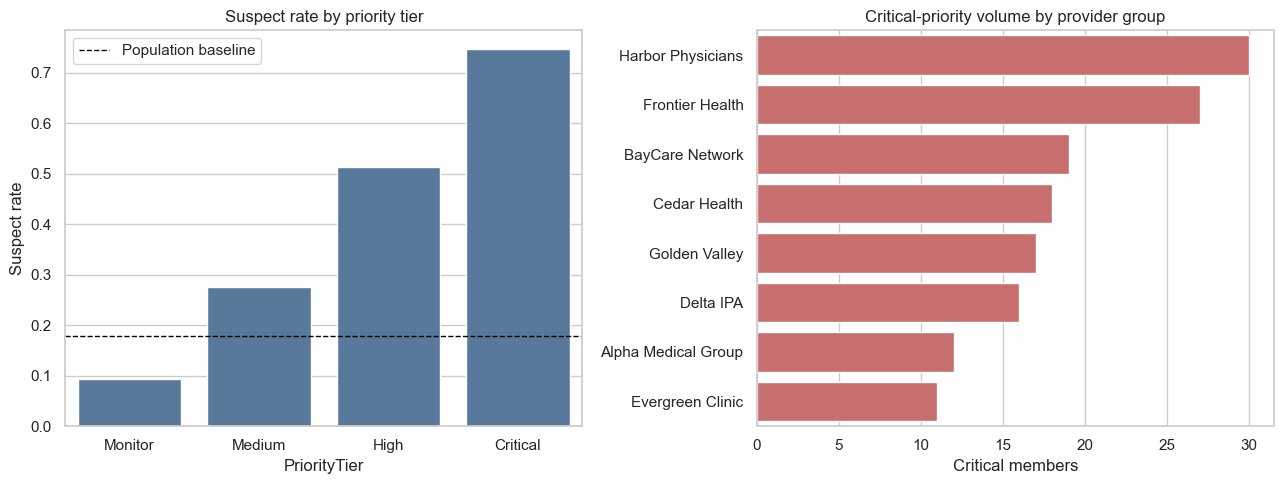

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=priority_summary, x="PriorityTier", y="SuspectRate", ax=axes[0], color="#4c78a8")
axes[0].axhline(df[TARGET].mean(), color="black", linestyle="--", linewidth=1, label="Population baseline")
axes[0].set_title("Suspect rate by priority tier")
axes[0].set_ylabel("Suspect rate")
axes[0].legend()

sns.barplot(
    data=provider_table.head(8),
    y="ProviderGroup",
    x="CriticalMembers",
    ax=axes[1],
    color="#d65f5f",
)
axes[1].set_title("Critical-priority volume by provider group")
axes[1].set_xlabel("Critical members")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "priority_queue_summary.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Statistical validation and risk adjustment checks

The validation layer demonstrates analyst-level healthcare reasoning: test whether RAF differs across selected regions, check whether suspect status varies by gender, and fit an adjusted RAF model to understand expected risk drivers.


In [11]:
west = df.loc[df["Region"] == "West", "RAF_Score"]
south = df.loc[df["Region"] == "South", "RAF_Score"]
t_stat, p_value = stats.ttest_ind(west, south, equal_var=False)
print(f"Welch t-test: West vs South RAF score -> t={t_stat:.3f}, p={p_value:.4f}")

contingency = pd.crosstab(df["Gender"], df[TARGET])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: Gender vs suspect flag -> chi2={chi2:.3f}, p={chi_p:.4f}, dof={dof}")
display(contingency)

adjustment_features = ["Age", "ChronicCount", "Prior_HCC_Flag", "New_Diagnosis_Flag", "ER_Visits", "Inpatient_Admits"]
x_adj = sm.add_constant(df[adjustment_features])
ols = sm.OLS(df["RAF_Score"], x_adj).fit()
adjusted_summary = pd.DataFrame(
    {
        "Coefficient": ols.params,
        "PValue": ols.pvalues,
    }
).round(4)
display(adjusted_summary)
print(f"Adjusted RAF model R-squared: {ols.rsquared:.3f}")


Welch t-test: West vs South RAF score -> t=0.011, p=0.9916
Chi-square: Gender vs suspect flag -> chi2=0.717, p=0.3970, dof=1


SuspectFlag,0,1
Gender,,
F,2118,477
M,1986,419


,Coefficient,PValue
const,0.048,0.000
Age,0.006,0.000
ChronicCount,0.406,0.000
Prior_HCC_Flag,0.229,0.000
New_Diagnosis_Flag,0.002,0.813
ER_Visits,0.003,0.610
Inpatient_Admits,0.015,0.035


Adjusted RAF model R-squared: 0.795


## 7. Plan-level risk transfer illustration

The project includes a simplified risk-transfer model to show how plan actuarial value, member months, and risk scores can be translated into an interpretable financial view. This is illustrative, not a regulatory payment calculation.


,PlanID,WeightedRisk,PLRS,TotalMemberMonths,TransferPMPM,TransferDirection
0,PlanB_Gold,0.672,0.537,15222,32.107,Receivable
1,PlanA_Silver,0.647,0.453,20007,-5.974,Payable
2,PlanC_Bronze,0.631,0.378,9354,-39.469,Payable


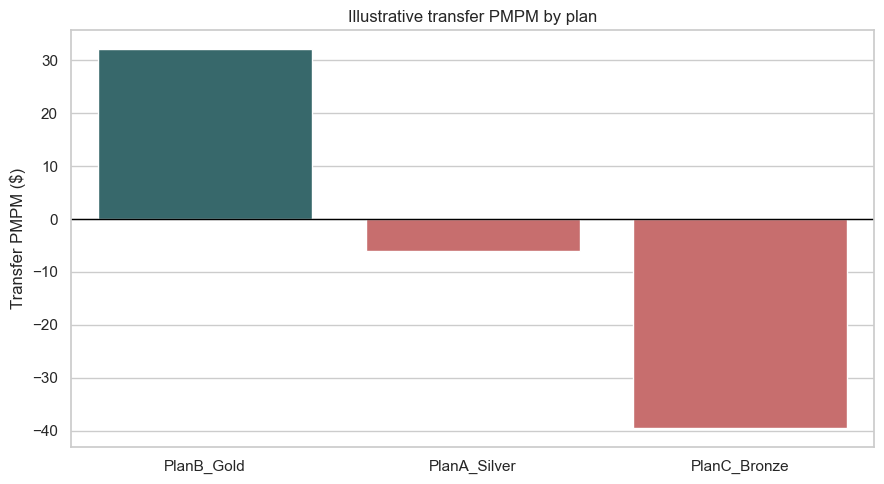

In [12]:
transfer_table = plan_transfer_table(df, premium_pmpm=450)
transfer_table.to_csv(OUTPUT_DIR / "plan_risk_transfer_summary.csv", index=False)
display(transfer_table.round(3))

plt.figure(figsize=(9, 5))
colors = transfer_table["TransferPMPM"].map(lambda value: "#2f6f73" if value > 0 else "#d65f5f")
sns.barplot(data=transfer_table, x="PlanID", y="TransferPMPM", palette=list(colors))
plt.axhline(0, color="black", linewidth=1)
plt.title("Illustrative transfer PMPM by plan")
plt.xlabel("")
plt.ylabel("Transfer PMPM ($)")
plt.tight_layout()
plt.savefig(FIG_DIR / "plan_risk_transfer.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Executive interpretation

### What this project demonstrates

- Built a HIPAA-safe synthetic healthcare member dataset with payer-style variables: RAF, utilization, chronic burden, care gaps, member months, actuarial value, and plan identifiers.
- Trained and compared predictive models for suspect member prioritization using healthcare-relevant evaluation metrics.
- Converted model scores into an operational review queue with priority tiers, provider group summaries, and top-member worklists.
- Added statistical validation and a simplified risk-transfer layer to connect analytics outputs to healthcare finance and operations.

### Recommended business use

- Use the critical and high tiers to focus chart review and provider outreach capacity.
- Track provider groups with both high suspect rate and high critical-priority volume.
- Monitor fairness and operational risk by reviewing performance across demographic and market segments.
- Refresh the scoring logic monthly as new claims, diagnosis, and encounter data become available.

### Portfolio positioning

This is strongest as a healthcare analytics / data science portfolio project because it combines domain understanding, predictive modeling, business KPIs, statistical testing, and an analyst-ready output workflow rather than stopping at charts or a basic model score.
